In [1]:
import seaborn as sns
import torch
import numpy as np
import hashlib
import matplotlib.pyplot as plt 
import sklearn
import os
import json, glob, os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from torch.nn import functional as F
from eeg_bench.config import get_config_value

In [2]:
from scipy.ndimage import gaussian_filter1d


In [70]:
#radraid2/spanchavati/eegfm/lightning_logs_v2/v2_lejepa_pretraining_global_v2mixer_proj/version_0/checkpoints/last.ckpt

from pathlib import Path
from eeg_bench.models.clinical.EEGLejepa_model import EMBED_CACHE_VERSION

TASK_NAME = "seizure_clinical" #"seizure_clinical"  # set to "sleep_staging" for sleep
SPLIT = "train"
CKPT_PATH = "/radraid2/spanchavati/eegfm/lightning_logs_v2/v2_lejepa_pretraining_global_v2mixer_proj_02sigreg/version_2/checkpoints/last.ckpt"
ATTENTIVE_PROBE = True
USE_GLOBAL_PCA = False

# Map friendly task names to cache task names
TASK_ALIASES = {
    "sleep_staging": "sleep_stages",
}

def _norm_task(task):
    return TASK_ALIASES.get(task, task)

def _ckpt_hash(ckpt_path):
    return hashlib.md5(str(ckpt_path).encode()).hexdigest()[:12]

def find_lejepa_index(task, ckpt_path, split="train", attentive=True):
    task = _norm_task(task)
    cache_dir = Path(get_config_value("cache", ".cache")) / "lejepa_embeddings"
    ckpt_hash = _ckpt_hash(ckpt_path)
    if attentive:
        pattern = f"{task}_{ckpt_hash}_*_{split}_seq_{EMBED_CACHE_VERSION}.index.json"
    else:
        pattern = f"{task}_{ckpt_hash}_*_{split}_{EMBED_CACHE_VERSION}.index.json"
    matches = sorted(cache_dir.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(f"No cache index found for pattern: {cache_dir / pattern}")
    return matches[0]

def find_h5(task, model_tag):
    task = _norm_task(task)
    h5_root = get_config_value("make_dataset") or os.path.join(get_config_value("data"), "make_dataset")
    pattern = os.path.join(h5_root, f"{task}_{model_tag}_*.h5")
    matches = sorted(glob.glob(pattern))
    #we need to pick the one with the highest number of samples (largest file size)
    matches = sorted(matches, key=lambda p: os.path.getsize(p), reverse=True)
    if not matches:
        raise FileNotFoundError(f"No H5 found for pattern: {pattern}")
    return matches[0]

sfreq = 250  # adjust if needed
index_path = find_lejepa_index(TASK_NAME, CKPT_PATH, split=SPLIT, attentive=ATTENTIVE_PROBE)
print("Using index:", index_path)

with open(index_path, "r") as f:
    index = json.load(f)

# Locate the H5 dataset (recording cache)
h5_path = find_h5(TASK_NAME, "LeJEPAClinical")
print("Using H5:", h5_path)

# Locate the LaBraM H5 dataset (recording cache)
try:
    if TASK_NAME == "seizure_clinical":
        labram_h5_path = '/radraid2/spanchavati/EEGBench/data/make_dataset/seizure_clinical_LaBraMModel_CHB-MIT_16_True_526.h5'
    else:
        labram_h5_path = '/radraid2/spanchavati/EEGBench/data/make_dataset/sleep_stages_clinical_LaBraMModel_Sleep-Telemetry_16_True_34.h5'
    print("Using LaBraM H5:", labram_h5_path)
except FileNotFoundError:
    labram_h5_path = None
    print("WARN: No LaBraM H5 found for task. Set labram_h5_path manually if needed.")

# Find a chunk with mixed labels (has both 0 and 1)
mixed = []
for shard in index["shards"]:
    labels = np.load(shard["labels"], mmap_mode="r")
    seq_ids = shard["sequence_ids"]
    for i in range(len(labels)):
        if np.unique(labels[i]).size > 1:
            mixed.append({
                "seq_id": seq_ids[i],
                "labels": labels[i].copy(),
                "emb": np.load(shard["embeddings"], mmap_mode="r")[i].copy()
            })
            # break
    # if mixed:
    #     break


def get_eeg_from_seq_id(seq_id):
    with h5py.File(h5_path, "r") as hf:
        eeg = hf[f"/recordings/{seq_id}/data"][:]  # (C, T)
        ch_names = hf[f"/recordings/{seq_id}/channels"][:]
    return eeg, ch_names


def get_labram_eeg_from_seq_id(seq_id):
    if labram_h5_path is None:
        raise FileNotFoundError("LaBraM H5 not found. Set labram_h5_path or check pattern.")
    with h5py.File(labram_h5_path, "r") as hf:
        eeg = hf[f"/recordings/{seq_id}/data"][:]  # (C, T)
        ch_names = hf[f"/recordings/{seq_id}/channels"][:]
    return eeg, ch_names

# Plot one of the mixed chunks
def plot_chunk_with_embeddings(mixed_chunk, embeddings, sfreq=250, global_pca=None, pca_min=None, pca_max=None, title=None, ax=None, eeg_override=None, ch_names_override=None):
    seq_id = mixed_chunk["seq_id"]
    labels = mixed_chunk["labels"]

    # Do PCA to get colors for the embeddings
    embeddings = embeddings.squeeze(0)  # (T, D)
    
    #norm the embeddings
    emb_mean = np.mean(embeddings, axis=0, keepdims=True)
    emb_std = np.std(embeddings, axis=0, keepdims=True) + 1e-8
    # embeddings = (embeddings - emb_mean) / emb_std
    
    if global_pca is not None:
        emb_pca = global_pca.transform(embeddings)
        if emb_pca.shape[1] > 3:
            emb_pca = emb_pca[:, 1:4]
    else:
        pca = sklearn.decomposition.PCA(n_components=3)  # RGB
        emb_pca = pca.fit_transform(embeddings)  # (T, 3)

    # Normalize to [0, 1] for visualization
    # if pca_min is None or pca_max is None:
    #     emb_pca_min = emb_pca.min(axis=0, keepdims=True)
    #     emb_pca_max = emb_pca.max(axis=0, keepdims=True)
    # else:
    #     emb_pca_min = pca_min
    #     emb_pca_max = pca_max
    # emb_pca_norm = (emb_pca - emb_pca_min) / (emb_pca_max - emb_pca_min + 1e-8)
    # emb_pca_norm = np.clip(emb_pca_norm, 0.0, 1.0)

    p_low = np.percentile(emb_pca, 2, axis=0, keepdims=True)
    p_high = np.percentile(emb_pca, 98, axis=0, keepdims=True)
    
    # Avoid division by zero if flat signal
    range_span = p_high - p_low
    range_span[range_span == 0] = 1e-8

    emb_pca_norm = (emb_pca - p_low) / range_span
    emb_pca_norm = np.clip(emb_pca_norm, 0.0, 1.0)

    # Get EEG data
    if eeg_override is None:
        eeg, ch_names = get_eeg_from_seq_id(seq_id)
    else:
        eeg, ch_names = eeg_override, ch_names_override

    C, T = eeg.shape
    t = np.arange(T) / sfreq

    if ax is None:
        plt.figure(figsize=(12, 6))
        ax = plt.gca()

        

    # Shade PCA colors across time (align spans to embedding windows)
    bounds = np.linspace(0, T, len(emb_pca_norm) + 1).astype(int)
    for i, color in enumerate(emb_pca_norm):
        ax.axvspan(bounds[i] / sfreq, bounds[i + 1] / sfreq, color=color, alpha=0.5, linewidth=.1)

    # Plot all channels with vertical offsets
    ch_std = np.std(eeg, axis=1)
    scale = float(np.median(ch_std[np.isfinite(ch_std)])) if np.any(np.isfinite(ch_std)) else 1.0
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    offset = 4.0 * scale

    for c in range(C):
        ax.plot(t, eeg[c] + c * offset, color="black", linewidth=0.6)

    # Y-axis ticks/labels (channel names)
    names = [
        (n.decode() if isinstance(n, (bytes, np.bytes_)) else str(n))
        for n in ch_names
    ]
    ax.set_yticks(np.arange(C) * offset)
    ax.set_yticklabels(names, fontsize=8)

    ax.set_xlim(t[0], t[-1])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Channels (offset)")

    # Labels overlay (upsample 1 Hz labels to match embedding windows)
    if len(labels) != len(emb_pca_norm):
        print("Normalizing Label Length from", len(labels), "to", len(emb_pca_norm))
        repeat = int(round(len(emb_pca_norm) / len(labels)))
        labels_plot = np.repeat(labels, repeat)[:len(emb_pca_norm)]
    else:
        labels_plot = labels

    # ax2 = ax.twinx()
    # # use the same bounds as the PCA windows so time aligns
    # label_times = bounds / sfreq
    # label_vals = np.concatenate([labels_plot, labels_plot[-1:]])
    # ax2.step(label_times, label_vals, where="post", color="red", linewidth=1.5)

    # chunk_len_s = index["meta"]["chunk_len_s"]  # expect 16
    # n_emb = embeddings.shape[0]
    # embed_dt = chunk_len_s / n_emb
    # print(len(labels), n_emb, embed_dt)  # should print 16, 160, 0.1

    # ...existing code...
    # Draw a red bar at the bottom for seizure periods
    ymin, ymax = ax.get_ylim()
    bar_y = ymin - 0.05 * (ymax - ymin)  # slightly below the lowest channel
    bar_height = 0.03 * (ymax - ymin)
    for i, val in enumerate(labels_plot):
        if val == 1:
            ax.add_patch(
                plt.Rectangle(
                    (bounds[i] / sfreq, bar_y),
                    (bounds[i + 1] - bounds[i]) / sfreq,
                    bar_height,
                    color="red",
                    alpha=0.8,
                    linewidth=0,
                    # z_order=10,
                )
            )
    # ...existing code...
    ax.set_ylim(bar_y - bar_height, ymax)

    



    # ax2.set_ylabel("Label")
    # ax2.set_ylim(-0.1, 1.1)

    if title:
        ax.set_title(title)


def plot_chunk(mixed_chunk, sfreq=250, global_pca=None, pca_min=None, pca_max=None, title=None, ax=None):
    return plot_chunk_with_embeddings(
        mixed_chunk,
        mixed_chunk["emb"],
        sfreq=sfreq,
        global_pca=global_pca,
        pca_min=pca_min,
        pca_max=pca_max,
        title=title,
        ax=ax,
    )


Using index: cache/lejepa_embeddings/seizure_clinical_25ef9b1d5954_52484b56b8f6_train_seq_v2.index.json
Using H5: ./data/make_dataset/seizure_clinical_LeJEPAClinical_CHB-MIT_16_True_526.h5
Using LaBraM H5: /radraid2/spanchavati/EEGBench/data/make_dataset/seizure_clinical_LaBraMModel_CHB-MIT_16_True_526.h5


In [49]:
idx = 150

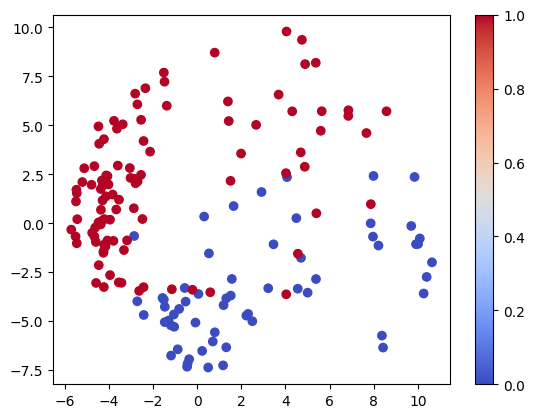

In [50]:
pc_mapper = sklearn.decomposition.PCA(n_components=3)
transformed = pc_mapper.fit_transform(mixed[idx]['emb'].squeeze())
plt.scatter(transformed[:,0], transformed[:,1], c = np.repeat(mixed[idx]['labels'], 10), cmap='coolwarm')
plt.colorbar()

Normalizing Label Length from 16 to 160


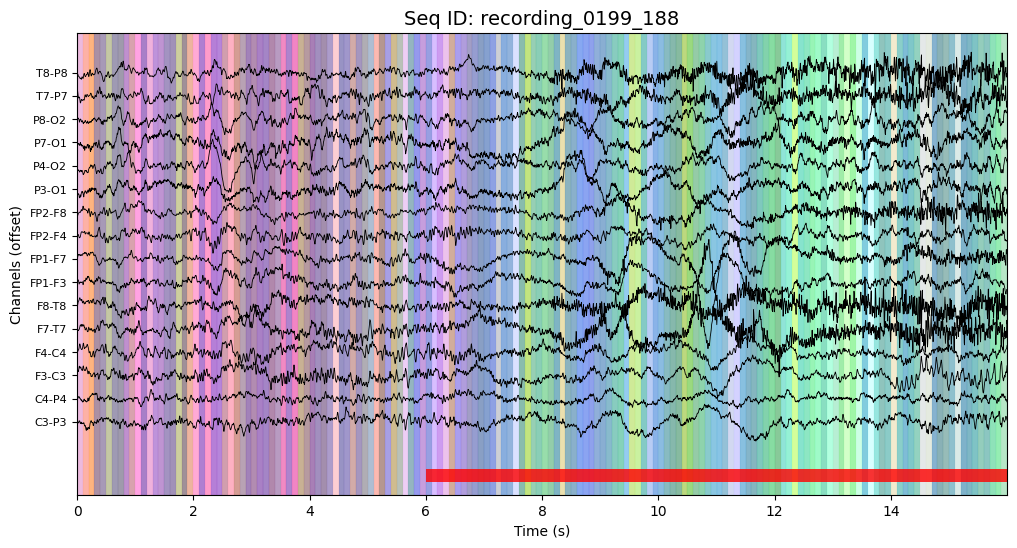

In [51]:
#check one mixed
plot_chunk(mixed[150], sfreq=sfreq, title=f"Seq ID: {mixed[0]['seq_id']}")

In [52]:
if USE_GLOBAL_PCA:
    N_embeddings = 1000
    all_embeddings = []
    for shard in index["shards"]:
        labels = np.load(shard["labels"], mmap_mode="r")
        seq_ids = shard["sequence_ids"]
        for i in range(len(labels)):
            all_embeddings.append(np.load(shard["embeddings"], mmap_mode="r")[i].squeeze(0))  # (T, D)
            if len(all_embeddings) >= N_embeddings:
                break
        if len(all_embeddings) >= N_embeddings:
            break

    global_embeddings = np.concatenate(all_embeddings, axis=0)  # (N, D)

    # Center the embeddings
    embeddings = global_embeddings - np.mean(global_embeddings, axis=0, keepdims=True)
    print("Global embeddings shape:", global_embeddings.shape)
    global_pca = sklearn.decomposition.PCA(n_components=3)
    global_pca.fit(global_embeddings)

    # Use a global min/max for consistent colors across chunks
    all_pca = global_pca.transform(global_embeddings)
    if all_pca.shape[1] > 3:
        all_pca = all_pca[:, 1:4]
    pca_min = all_pca.min(axis=0, keepdims=True)
    pca_max = all_pca.max(axis=0, keepdims=True)
else:
    global_pca = None
    pca_min = None
    pca_max = None


Normalizing Label Length from 16 to 160
Normalizing Label Length from 16 to 160
Normalizing Label Length from 16 to 160
Normalizing Label Length from 16 to 160
Normalizing Label Length from 16 to 160


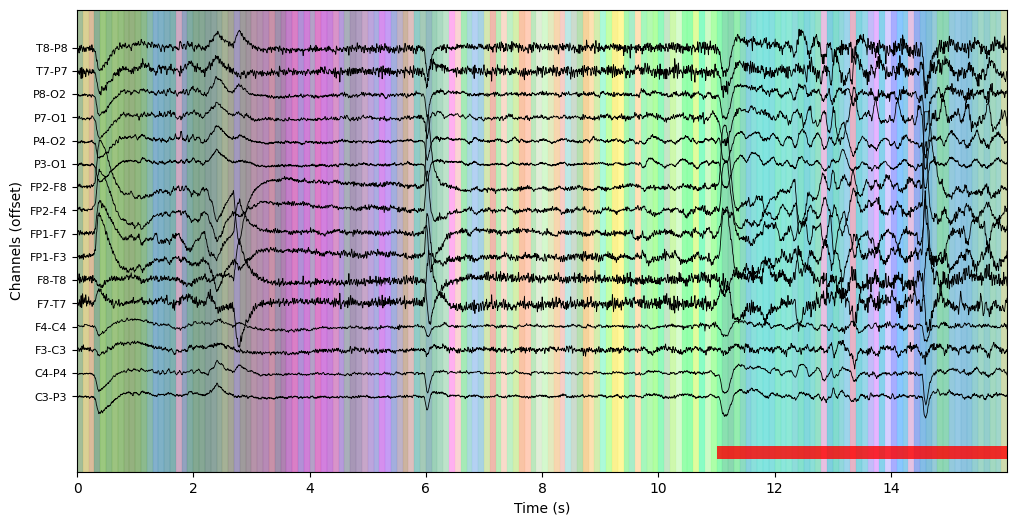

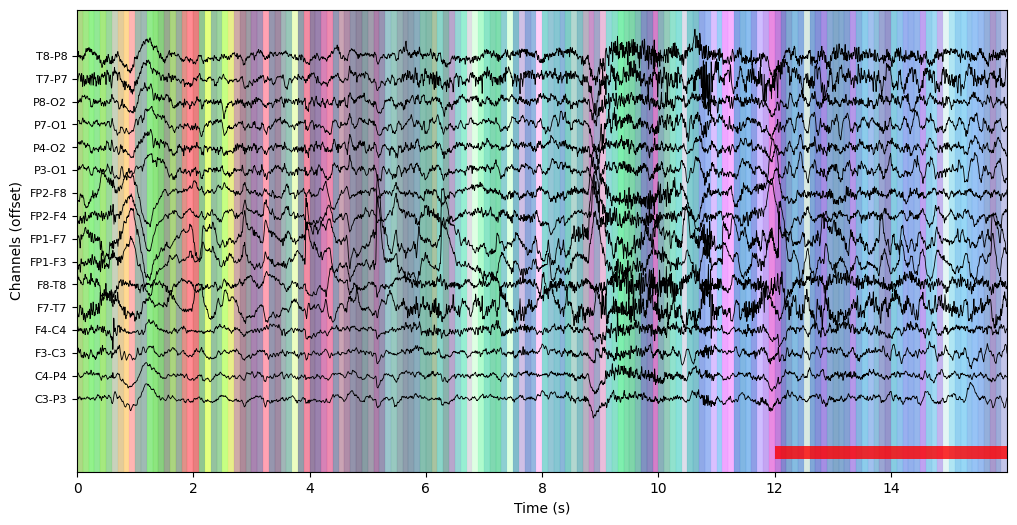

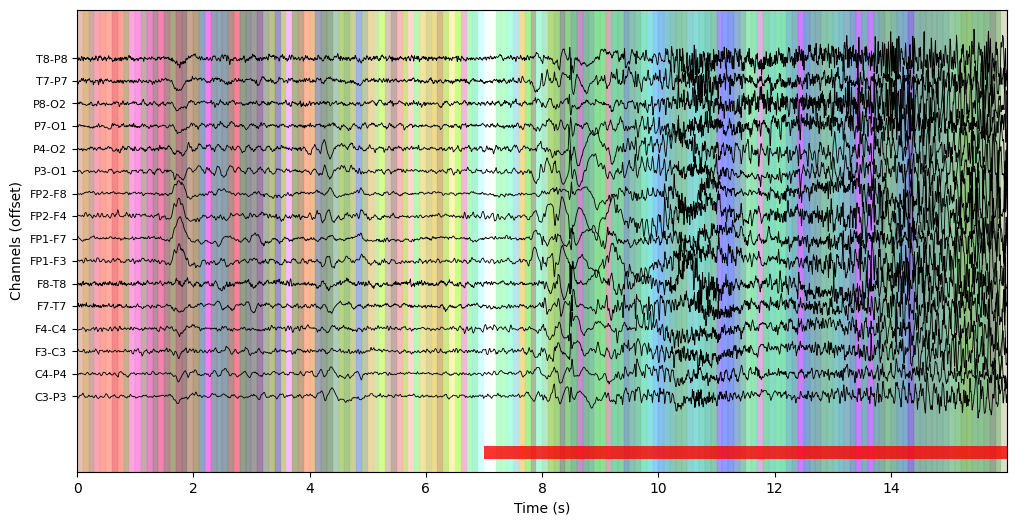

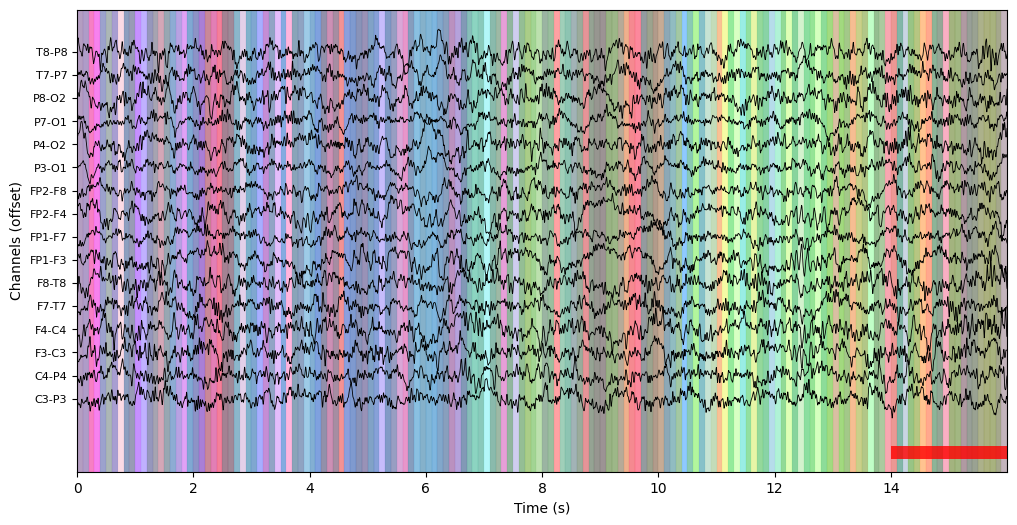

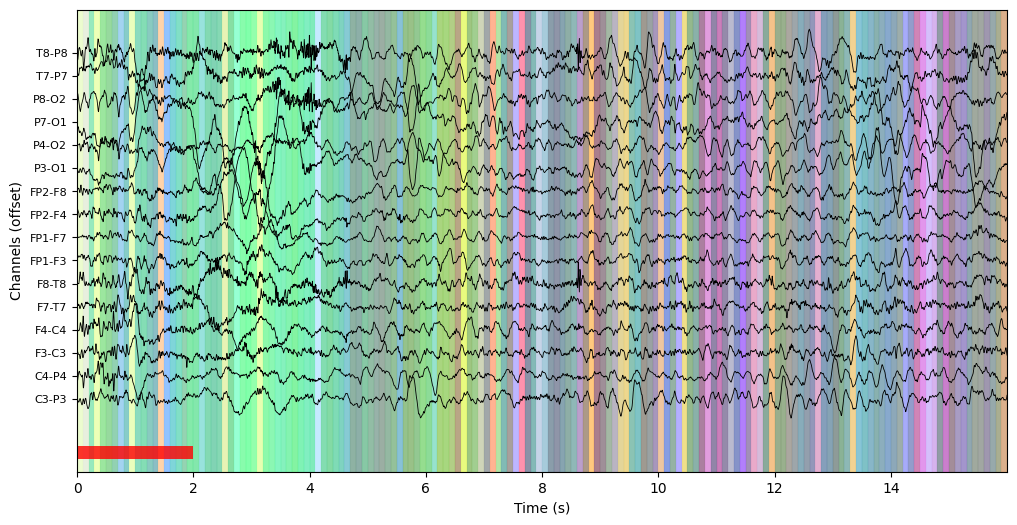

In [53]:
CHUNKS_TO_PLOT = 5
#get random indices to plot 
idx_to_plot = np.random.choice(len(mixed), size=min(CHUNKS_TO_PLOT, len(mixed)), replace=False)
for i in idx_to_plot:
    plot_chunk(mixed[i], global_pca=global_pca, pca_min=pca_min, pca_max=pca_max)

In [71]:
from eeg_bench.models.clinical.labram_model import check_and_download_pretrained_model
from eeg_bench.models.clinical.LaBraM import utils as labram_utils
from eeg_bench.models.clinical.LaBraM import modeling_finetune  # noqa: F401
from timm.models import create_model
from scipy.signal import resample

# Load LaBraM base model
labram_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(check_and_download_pretrained_model(), map_location="cpu", weights_only = False)
new_checkpoint = {}
for k, v in checkpoint["model"].items():
    if k.startswith("student."):
        new_checkpoint[k[len("student."):]] = v

labram_model = create_model(
    "labram_base_patch200_200",
    qkv_bias=False,
    rel_pos_bias=True,
    num_classes=0,
    drop_rate=0.0,
    drop_path_rate=0.1,
    attn_drop_rate=0.0,
    drop_block_rate=None,
    use_mean_pooling=True,
    init_scale=0.001,
    use_rel_pos_bias=True,
    use_abs_pos_emb=True,
    init_values=0.1,
)
labram_model.load_state_dict(new_checkpoint, strict=False)
labram_model.to(labram_device).eval()


def labram_embeddings_for_seq_id(seq_id, orig_sfreq=250, target_sfreq=200):
    eeg, ch_names = get_eeg_from_seq_id(seq_id)

    # Resample to 200 Hz for LaBraM
    if orig_sfreq != target_sfreq:
        new_T = int(round(eeg.shape[1] * target_sfreq / orig_sfreq))
        eeg_rs = resample(eeg, new_T, axis=1)
    else:
        eeg_rs = eeg

    # Crop to multiple of 200 samples
    T = eeg_rs.shape[1] - (eeg_rs.shape[1] % 200)
    eeg_rs = eeg_rs[:, :T]

    tokens = torch.from_numpy(eeg_rs).float().unsqueeze(0)
    tokens = tokens.reshape(1, eeg_rs.shape[0], T // 200, 200) / 100.0

    names = [(n.decode() if isinstance(n, (bytes, np.bytes_)) else str(n)) for n in ch_names]
    input_chans = labram_utils.get_input_chans([n.upper() for n in names])
    print(names)

    print(f"Using input channels: {input_chans}")
    if 'EOGh' in input_chans:
        #drop it! 
        input_chans = input_chans[:-1]
        tokens = tokens[:, :len(input_chans), :, :]

    with torch.no_grad():
        emb = labram_model.forward_features(
            tokens.to(labram_device),
            input_chans=input_chans,
            return_patch_tokens=True,
        )

    return emb.cpu().numpy(), eeg_rs, ch_names


In [72]:
sns.set_context('poster')

In [73]:
good_idx = None
for i, mix in enumerate(mixed):
    if 'recording_0314_066' in mix["seq_id"]:
        good_idx = i
        break

In [74]:
i

49

WARN: Using non-(standard-)LaBraM input channels
['C3-P3', 'C4-P4', 'F3-C3', 'F4-C4', 'F7-T7', 'F8-T8', 'FP1-F3', 'FP1-F7', 'FP2-F4', 'FP2-F8', 'P3-O1', 'P4-O2', 'P7-O1', 'P8-O2', 'T7-P7', 'T8-P8']
Using input channels: range(0, 17)
Normalizing Label Length from 16 to 160
Normalizing Label Length from 16 to 256


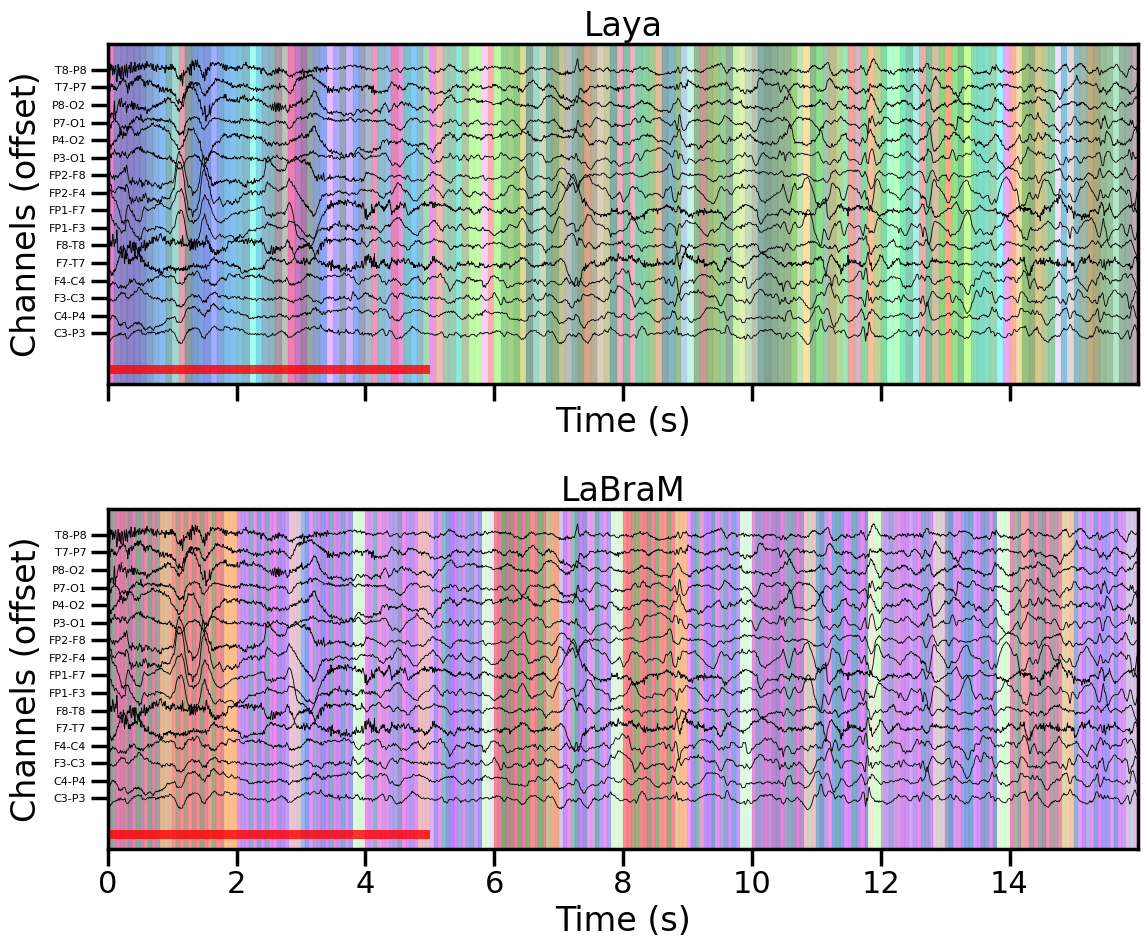

In [ ]:
CHUNKS_TO_COMPARE = 10
idx_to_compare = np.random.choice(len(mixed), size=min(CHUNKS_TO_COMPARE, len(mixed)), replace=False)
idx_to_compare = np.append(idx_to_compare, idx)  # also include the earlier idx

for i in [good_idx]: #idx_to_compare[0]:
    seq_id = mixed[i]["seq_id"]
    # print(seq_id)
    labram_emb, labram_eeg, labram_ch_names = labram_embeddings_for_seq_id(seq_id, orig_sfreq=sfreq, target_sfreq=200)

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    plot_chunk_with_embeddings(
        mixed[i],
        mixed[i]["emb"],
        sfreq=sfreq,
        global_pca=global_pca,
        pca_min=pca_min,
        pca_max=pca_max,
        title="Laya",
        ax=axes[0],
    )
    plot_chunk_with_embeddings(
        mixed[i],
        labram_emb,
        sfreq=200,
        global_pca=None,
        title="LaBraM",
        ax=axes[1],
        eeg_override=labram_eeg,
        ch_names_override=labram_ch_names,
    )
    plt.tight_layout()
    

    plt.savefig(f"figures/representative_pca_2.png", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# ================================================================
# BCI Embedding PCA Analysis  (Laya / EEGLEJEPA)
# ================================================================
# Set BCI_CKPT_PATH to a trained checkpoint before running.
# The checkpoint must live in  version_N/checkpoints/last.ckpt
# and  version_N/config/config.pkl  must be present.
# ================================================================

BCI_CKPT_PATH = "/path/to/checkpoint.ckpt"   # ← FILL IN
BCI_SUBJECTS  = [1, 2, 3]                     # PhysionetMI subjects
N_TRIALS_VIZ  = 40                            # trials to stitch
BCI_TASK_NAME = "Left Hand vs Right Hand MI"

In [ ]:
from eeg_bench.datasets.bci.physionetmi_m import PhysionetMIMDataset
from eeg_bench.enums.bci_classes import BCIClasses
from eeg_bench.models.bci.LaBraM.make_dataset import make_dataset_lejepa

pmi_ds = PhysionetMIMDataset(
    target_classes=[BCIClasses.LEFT_HAND_MI, BCIClasses.RIGHT_HAND_MI],
    subjects=BCI_SUBJECTS,
    preload=True,
)
bci_X    = pmi_ds.data
bci_y    = pmi_ds.labels
bci_meta = pmi_ds.meta
ch_names_bci = list(bci_meta["channel_names"])
sfreq_raw    = bci_meta["sampling_frequency"]
print(f"Raw: {bci_X.shape}  sfreq={sfreq_raw}  classes={np.unique(bci_y)}")

# Preprocess: bandpass, notch, resample → 250 Hz, keep standard-1020 channels
# train=False returns all trials without a val split
bci_ds = make_dataset_lejepa(
    bci_X, bci_y, BCI_TASK_NAME, sfreq_raw, ch_names_bci, train=False,
)
BCI_SFREQ     = 250
ch_names_proc = np.array(bci_ds.ch_names)
print(f"Post-preproc: {bci_ds.data.shape}  channels={len(ch_names_proc)}")

In [ ]:
import sys, pickle
from pathlib import Path
from transformers import AutoModel

# ── eegfm / laya path ──────────────────────────────────────────────────
_eegfm_path    = get_config_value("lejepa", {}).get("eegfm_path")
_pos_bank_path = get_config_value("lejepa", {}).get("pos_bank_path", "./REVE_posbank")
if _eegfm_path and _eegfm_path not in sys.path:
    sys.path.insert(0, _eegfm_path)

from eegfmchallenge.models.eeglejepa import EEGLEJEPAConfig

bci_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Position bank ───────────────────────────────────────────────────────
bci_pos_bank = AutoModel.from_pretrained(
    _pos_bank_path, trust_remote_code=True
).to(bci_device)

# ── Resolve config.pkl from checkpoint path ─────────────────────────────
_ckpt_p       = Path(BCI_CKPT_PATH)
_config_path  = None
if _ckpt_p.parent.name == "checkpoints":
    _ver_dir = _ckpt_p.parent.parent
    if _ver_dir.name.startswith("version_"):
        _cand = _ver_dir / "config" / "config.pkl"
        if _cand.exists():
            _config_path = _cand
assert _config_path is not None, f"config.pkl not found near {BCI_CKPT_PATH}"

# ── Build model from saved config, then load pretrained weights ─────────
with open(_config_path, "rb") as _f:
    _pretrain_cfg = pickle.load(_f)

bci_model = EEGLEJEPAConfig(**_pretrain_cfg["model"]).build().to(bci_device)

_ckpt  = torch.load(_ckpt_p, map_location="cpu", weights_only=False)
_state = _ckpt.get("state_dict", _ckpt)
_state = {k.replace("model.", ""): v for k, v in _state.items()}
_res   = bci_model.load_state_dict(_state, strict=False)
print(f"Weights: matched={len(set(bci_model.state_dict()) & set(_state))}  "
      f"missing={len(_res.missing_keys)}  unexpected={len(_res.unexpected_keys)}")
bci_model.eval()
print(f"EEGLEJEPA ready on {bci_device}")

In [ ]:
from torch.utils.data import DataLoader

BCI_EMB_CACHE = Path(get_config_value("cache", ".cache")) / "lejepa_embeddings"
BCI_EMB_CACHE.mkdir(parents=True, exist_ok=True)
_ckpt_hash_bci  = hashlib.md5(str(BCI_CKPT_PATH).encode()).hexdigest()[:12]
_n_hash         = hashlib.md5(f"{len(bci_ds)}_{len(ch_names_proc)}".encode()).hexdigest()[:8]
_bci_cache_path = BCI_EMB_CACHE / f"bci_viz_{_ckpt_hash_bci}_{_n_hash}.npz"


def _get_bci_coords(ch_names):
    clean = [c.replace("EEG", "").strip() for c in ch_names]
    c = bci_pos_bank(clean)
    if isinstance(c, dict):
        c = c.get("positions", c.get("coords", c.get("last_hidden_state")))
    if c.dim() == 3:
        c = c.squeeze(0)
    c = c.float().to(bci_device)
    valid_mask = ~(torch.isnan(c).any(dim=-1) | (c.abs().sum(dim=-1) == 0))
    valid_idx  = torch.where(valid_mask)[0]
    return c[valid_idx], valid_idx


@torch.no_grad()
def _extract_bci_embeddings(dataset, ch_names, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    coords, valid_idx = _get_bci_coords(ch_names)
    embs, lbls = [], []
    for x, y in tqdm(loader, desc="Extracting BCI embeddings"):
        x = x[:, valid_idx, :].to(bci_device)
        cb = coords.unsqueeze(0).expand(x.size(0), -1, -1)
        # forward_downstream: no cropped views, full sequence, returns cls_token
        out = bci_model.forward_downstream(x=x, channel_locations=cb)
        cls = out["cls_token"]           # (B, dim)
        if cls.dim() == 3:
            cls = cls.mean(dim=1)
        embs.append(cls.cpu().numpy())
        lbls.append(y.argmax(dim=1).numpy() if y.dim() > 1 else y.numpy())
    return np.concatenate(embs), np.concatenate(lbls)


if _bci_cache_path.exists():
    print(f"Loading cached embeddings: {_bci_cache_path}")
    _d = np.load(_bci_cache_path)
    bci_embs, bci_labels = _d["embeddings"], _d["labels"]
else:
    bci_embs, bci_labels = _extract_bci_embeddings(bci_ds, ch_names_proc)
    np.savez_compressed(_bci_cache_path, embeddings=bci_embs, labels=bci_labels)
    print(f"Cached to {_bci_cache_path}")

print(f"Embeddings: {bci_embs.shape}   class counts: {np.bincount(bci_labels)}")

In [ ]:
from sklearn.decomposition import PCA

_bci_class_colors = ["#2196F3", "#F44336"]   # blue = left hand, red = right hand
_bci_class_names  = ["Left Hand", "Right Hand"]

_bci_pca2 = PCA(n_components=2)
_bci_2d   = _bci_pca2.fit_transform(bci_embs)

fig, ax = plt.subplots(figsize=(7, 6))
for _ci, (_col, _name) in enumerate(zip(_bci_class_colors, _bci_class_names)):
    _m = bci_labels == _ci
    ax.scatter(_bci_2d[_m, 0], _bci_2d[_m, 1],
               c=_col, label=_name, alpha=0.45, s=18, linewidths=0)
ax.set_xlabel(f"PC1 ({_bci_pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({_bci_pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("BCI Embedding Space – Laya (EEGLEJEPA) | PhysionetMI")
ax.legend(markerscale=2)
sns.despine()
os.makedirs("figures", exist_ok=True)
plt.tight_layout()
plt.savefig("figures/bci_pca_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Trials are discrete events with gaps between them; we stitch them
# into a pseudo-continuous display.  Each trial's time span is coloured
# by its embedding (PCA → RGB), and a ground-truth bar runs at the bottom.
# If the model tracks class identity the colour should toggle between
# left and right as the labels alternate.

_n_per_class = N_TRIALS_VIZ // 2
_idx_left    = np.where(bci_labels == 0)[0][:_n_per_class]
_idx_right   = np.where(bci_labels == 1)[0][:_n_per_class]
# Interleave classes for maximum visual contrast
_trial_idx   = np.array([x for pair in zip(_idx_left, _idx_right) for x in pair])

_sel_embs   = bci_embs[_trial_idx]        # (N_VIZ, D)
_sel_labels = bci_labels[_trial_idx]      # (N_VIZ,)
_sel_eegs   = bci_ds.data[_trial_idx]     # (N_VIZ, C, T)

# PCA 3-component → per-trial RGB colour
_bci_pca3  = PCA(n_components=3)
_embs_pca  = _bci_pca3.fit_transform(_sel_embs)
_p_low     = np.percentile(_embs_pca, 2,  axis=0)
_p_high    = np.percentile(_embs_pca, 98, axis=0)
_span      = np.where(_p_high - _p_low == 0, 1e-8, _p_high - _p_low)
_embs_rgb  = np.clip((_embs_pca - _p_low) / _span, 0, 1)   # (N_VIZ, 3)

# Stitch: (C, N_VIZ × T_trial)
_T_trial  = _sel_eegs.shape[2]
_stitched = np.concatenate(list(_sel_eegs), axis=1)
_C, _T_total = _stitched.shape
_t_ax    = np.arange(_T_total) / BCI_SFREQ
_N_viz   = len(_trial_idx)

fig, ax = plt.subplots(figsize=(22, 8))

# Background: embedding PCA colour per trial
for _i in range(_N_viz):
    _t0 = _i * _T_trial / BCI_SFREQ
    _t1 = (_i + 1) * _T_trial / BCI_SFREQ
    ax.axvspan(_t0, _t1, color=_embs_rgb[_i], alpha=0.45, linewidth=0)

# EEG traces
_ch_std = np.std(_stitched, axis=1)
_scale  = float(np.median(_ch_std[np.isfinite(_ch_std)])) or 1e-8
_offset = 4.0 * _scale
for _c in range(_C):
    ax.plot(_t_ax, _stitched[_c] + _c * _offset, color="black", linewidth=0.4, alpha=0.6)

# Y-axis: subsample channel labels
_tick_step = max(1, _C // 10)
ax.set_yticks(np.arange(_C)[::_tick_step] * _offset)
ax.set_yticklabels(ch_names_proc[::_tick_step], fontsize=7)

ax.set_xlim(0, _T_total / BCI_SFREQ)
ax.set_xlabel("Stitched time across trials (s)")
ax.set_ylabel("Channels (offset)")
ax.set_title("Laya (EEGLEJEPA) – Embedding PCA Colour over Stitched BCI Trials")

# Ground-truth class bar at the bottom
_ymin, _ymax = ax.get_ylim()
_bar_y = _ymin - 0.06 * (_ymax - _ymin)
_bar_h = 0.03 * (_ymax - _ymin)
_cls_bar_colors = ["#2196F3", "#F44336"]
for _i, _cls in enumerate(_sel_labels):
    ax.add_patch(plt.Rectangle(
        (_i * _T_trial / BCI_SFREQ, _bar_y), _T_trial / BCI_SFREQ, _bar_h,
        color=_cls_bar_colors[_cls], linewidth=0,
    ))
ax.set_ylim(_bar_y - _bar_h, _ymax)

# Vertical dividers between trials
for _i in range(1, _N_viz):
    ax.axvline(_i * _T_trial / BCI_SFREQ, color="gray", linewidth=0.5,
               linestyle="--", alpha=0.5)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=n)
                   for c, n in zip(_cls_bar_colors, ["Left Hand", "Right Hand"])],
          loc="upper right", title="Class (bar)")

plt.tight_layout()
plt.savefig("figures/bci_stitched_pca.png", dpi=200, bbox_inches="tight")
plt.show()